<a href="https://colab.research.google.com/github/dejuakim/PROJECT_aiffel/blob/master/DS8_%EB%89%B4%EC%8A%A4%EC%B9%B4%ED%85%8C%EA%B3%A0%EB%A6%AC_%EB%8B%A4%EC%A4%91%EB%B6%84%EB%A5%98%5B%ED%94%84%EB%A1%9C%EC%A0%9D%ED%8A%B8%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

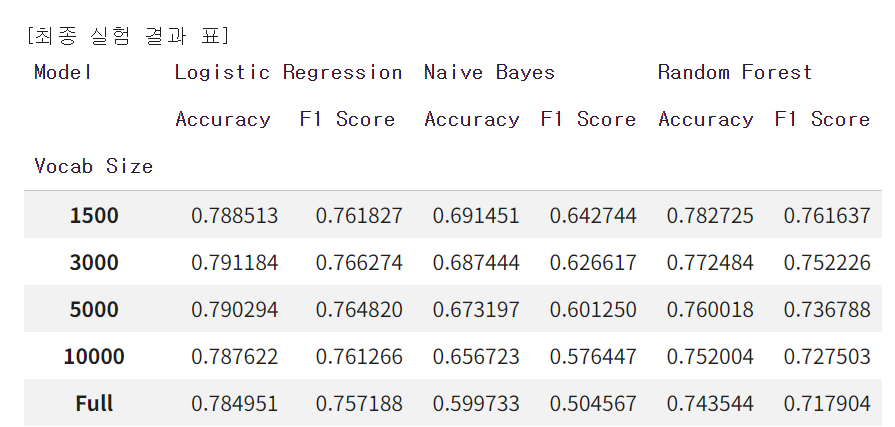

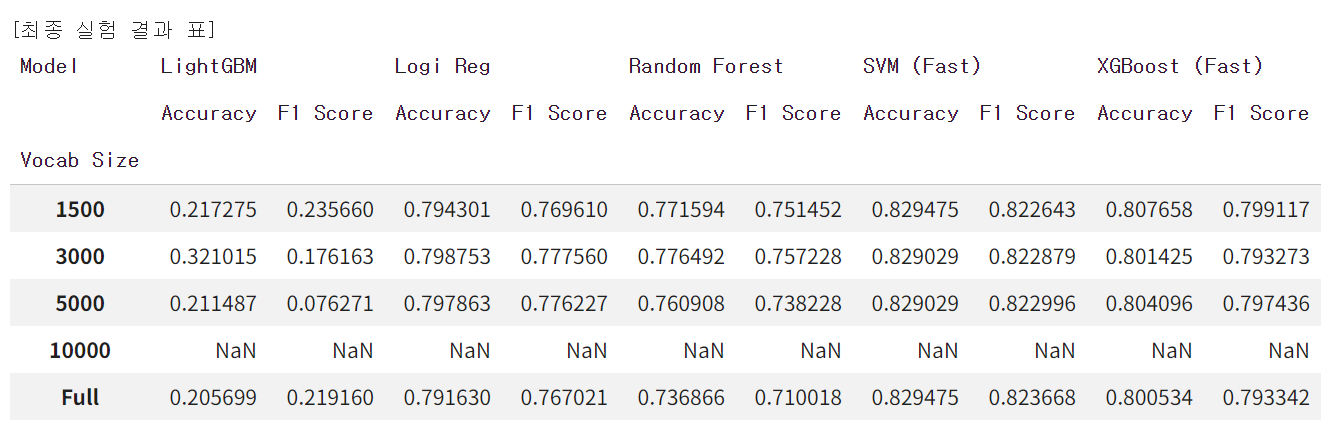

# 회고

> 제일좋은 모델은 SVM 모델이었다.

SVM > Logistic Regression > Random Forest > Naive Bayes

개수를 다양하게 적용하고 또 많은 모델을 사용해보고 싶어 욕심을 냈더니

시간이 너무 오래걸렸다.

그리고 중간에 에러가 발생해서 다시 해야하는 이슈ㅠㅜ

역시 욕심은 금물

흥미로운 부분은 단어 수가 많다고 무조건 좋은 건 아니라는 것이다. 대부분의 모델이 적은 단어수에서 최고점을 찍었다. SVM은 단어 수에 영향을 크게 받지 않는 것 같았다.

시간이 너무 걸려서 중간에 멈춰버려서 SVM 가성비 모델로 돌렸는데 성능이 좋아서 SVM 모델만 하이퍼파라미터 튜닝을 진행한 후 다시 돌려봤다.

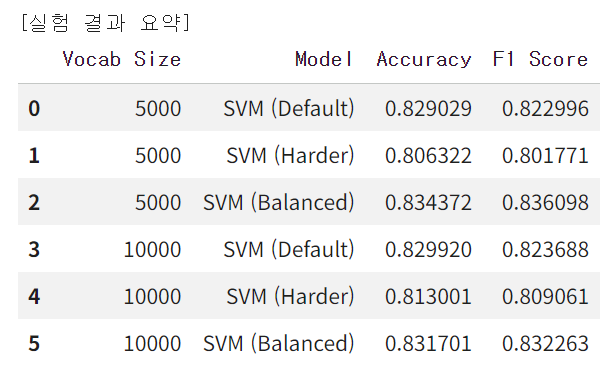

SVM (Balanced): 83.4%
- class_weight='balanced' 옵션을 준 모델이 적은 양의 뉴스 카테고리도 꼼꼼히 챙겼기 때문인지 가장 높은 점수가 나왔다.

SVM (Harder): 80.6%
- C값을 10으로 높였더니 오히려 점수가 떨어졌다. 너무 깐깐하게 공부해서 그런듯..

## 단어장 개수별 ML 모델 성능 비교 (Accuracy / F1-score)

| Vocabulary Size | Model             | Accuracy | F1-Score |
|------------------|------------------|----------|----------|
| 10000            | LogisticRegression |   0.79   |   0.76   |
|                  | SVM                |   0.83   |   0.82   |
|                  | RandomForest       |   0.75   |   0.72   |
|                  | XGBoost            |   0.80   |   0.79   |
|                  | NaiveBayes         |   0.66   |   0.58   |
|                  | LightGBM           |   0.76   |   0.59   |
| 5000             | LogisticRegression |   0.80   |   0.78   |
|                  | SVM                |   0.83   |   0.82   |
|                  | RandomForest       |   0.76   |   0.74   |
|                  | XGBoost            |   0.80   |   0.80   |
|                  | NaiveBayes         |   0.67   |   0.60   |
|                  | LightGBM           |   0.21   |   0.21   |
| NaN (All words)  | LogisticRegression |   0.79   |   0.77   |
|                  | SVM                |   0.83   |   0.82   |
|                  | RandomForest       |   0.74   |   0.72   |
|                  | XGBoost            |   0.80   |   0.79   |
|                  | NaiveBayes         |   0.60   |   0.50   |
|                  | LightGBM           |   0.21   |   0.22   |

2. 딥러닝과 머신런닝의 차이 비교하기
- 딥러닝 모델 1개 Dense를 이용해서 비교해보세요 평가지표 = accuacry, f1-score

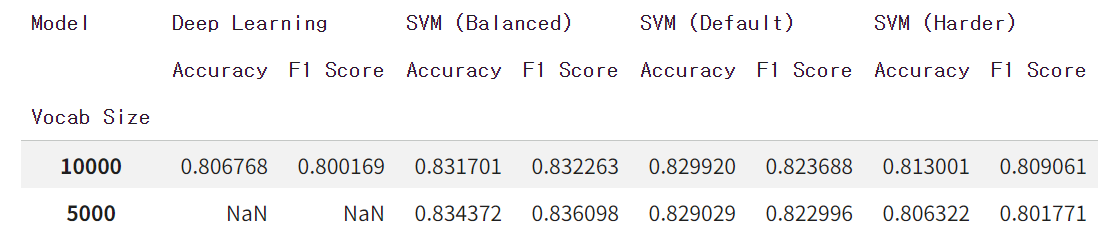

> 단순히 레이어를 쌓는다고 해서 딥러닝이 무조건 머신러닝을 이기는 것이 아니라 데이터의 특성에 따라 가장 잘 맞는 도구가 따로 있다!

In [1]:
from tensorflow.keras.datasets import reuters
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer

# 데이터 준비

## 훈련 데이터와 테스트 데이터 로드하기

In [2]:
# 모든 단어 사용
(x_train, y_train), (x_test, y_test) = reuters.load_data(num_words=None, test_split=0.2)

2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


훈련용 데이터 최대 길이 :2376
훈련용 데이터 평균 길이 :145.5398574927633


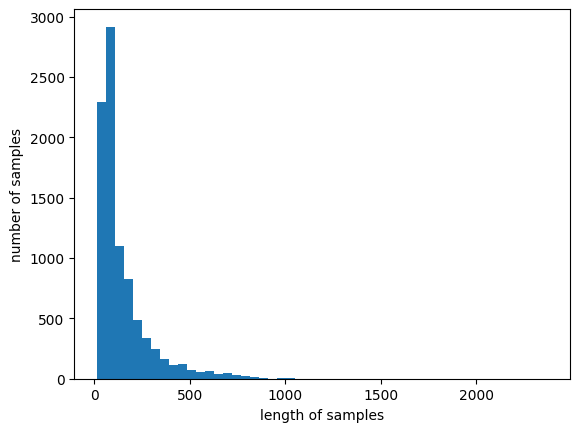

In [3]:
print('훈련용 데이터 최대 길이 :{}'.format(max(len(l) for l in x_train)))
print('훈련용 데이터 평균 길이 :{}'.format(sum(map(len, x_train))/len(x_train)))

plt.hist([len(s) for s in x_train], bins=50)
plt.xlabel('length of samples')
plt.ylabel('number of samples')
plt.show()

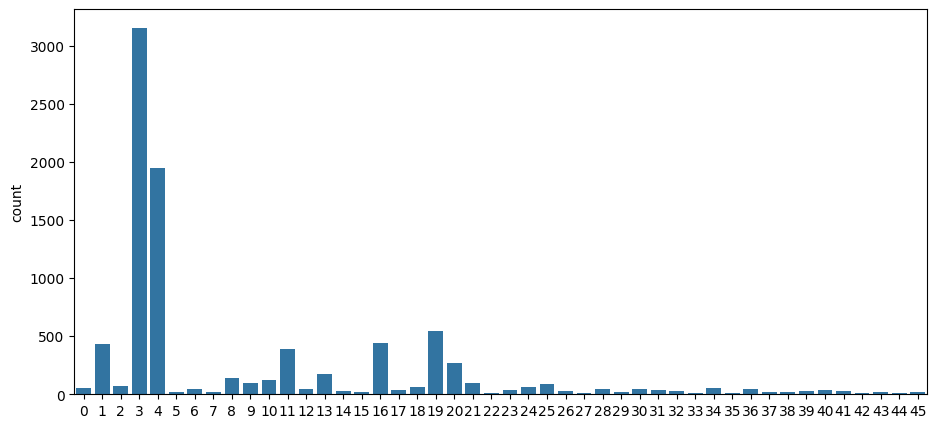

In [4]:
fig, axe = plt.subplots(ncols=1)
fig.set_size_inches(11,5)
sns.countplot(x=y_train)
plt.show()

In [5]:
unique_elements, counts_elements = np.unique(y_train, return_counts=True)
print("각 클래스 빈도수:")
print(np.asarray((unique_elements, counts_elements)))

각 클래스 빈도수:
[[   0    1    2    3    4    5    6    7    8    9   10   11   12   13
    14   15   16   17   18   19   20   21   22   23   24   25   26   27
    28   29   30   31   32   33   34   35   36   37   38   39   40   41
    42   43   44   45]
 [  55  432   74 3159 1949   17   48   16  139  101  124  390   49  172
    26   20  444   39   66  549  269  100   15   41   62   92   24   15
    48   19   45   39   32   11   50   10   49   19   19   24   36   30
    13   21   12   18]]


In [6]:
word_index = reuters.get_word_index(path="reuters_word_index.json")

550378/550378 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step


In [7]:
index_to_word = { index+3 : word for word, index in word_index.items() }
for index, token in enumerate(("<pad>", "<sos>", "<unk>")):
  index_to_word[index]=token

In [8]:
decoded = []
for i in range(len(x_train)):
    t = ' '.join([index_to_word[index] for index in x_train[i]])
    decoded.append(t)

x_train = decoded
print(len(x_train))

8982


In [9]:
decoded_test = []
for i in range(len(x_test)):
    t = ' '.join([index_to_word[index] for index in x_test[i]])
    decoded_test.append(t)

x_test = decoded_test
print(len(x_test))

2246


# 벡터화 하기

In [10]:
dtmvector = CountVectorizer()

tfidf_transformer = TfidfTransformer()

x_train_dtm = dtmvector.fit_transform(x_train)
x_test_dtm= dtmvector.transform(x_test)

x_train_tfidf = tfidf_transformer.fit_transform(x_train_dtm)
x_test_tfidf = tfidf_transformer.transform(x_test_dtm)

In [11]:
x_train_tfidf.shape

(8982, 26506)

In [12]:
x_test_tfidf.shape

(2246, 26506)

In [13]:
x_train[3]

"<sos> the farmers home administration the u s agriculture department's farm lending arm could lose about seven billion dlrs in outstanding principal on its severely delinquent borrowers or about one fourth of its farm loan portfolio the general accounting office gao said in remarks prepared for delivery to the senate agriculture committee brian crowley senior associate director of gao also said that a preliminary analysis of proposed changes in fmha's financial eligibility standards indicated as many as one half of fmha borrowers who received new loans from the agency in 1986 would be ineligible under the proposed system the agency has proposed evaluating applicants' credit using a variety of financial ratios instead of relying solely on cashflow ability senate agriculture committee chairman patrick leahy d vt slammed the proposed eligibility changes telling fmha administrator vance clark at a hearing that they would mark a dramatic shift in the agency's purpose away from being farmer

# 모델 정의 및 실험
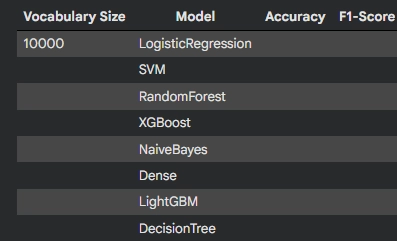

In [14]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import ComplementNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.svm import LinearSVC

### TF-idf데이터로 XGBoost 모델 학습하기

In [19]:
from xgboost import XGBClassifier

# XGBoost 모델 학습
xgb_model = XGBClassifier(n_estimators=100, max_depth=5, eval_metric='mlogloss')
xgb_model.fit(x_train_tfidf, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [20]:
# 예측
y_pred = xgb_model.predict(x_test_tfidf)

# 평가 지표
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')

print(f"✅ Accuracy : {acc:.4f}")
print(f"✅ F1-score : {f1:.4f}")

✅ Accuracy : 0.8005
✅ F1-score : 0.6292


### TF-idf데이터로 로지스틱 회귀(Logistic Regression) 모델 학습하기

In [21]:
lr_model = LogisticRegression(C=10000, penalty='l2', max_iter=3000)
lr_model.fit(x_train_tfidf, y_train)

LogisticRegression(C=10000, max_iter=3000)

In [22]:
# 예측
y_pred = lr_model.predict(x_test_tfidf)

# 평가 지표
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')

print(f"✅ Accuracy : {acc:.4f}")
print(f"✅ F1-score : {f1:.4f}")

✅ Accuracy : 0.8112
✅ F1-score : 0.6629


## 다중분류 자동 실험



In [23]:
# 1. Reuters 데이터를 텍스트로 복원하는 함수 (CountVectorizer 사용을 위해)
def decode_reuters(x_data):
    word_index = reuters.get_word_index()
    index_to_word = {i+3: word for word, i in word_index.items()}
    for i, word in enumerate(('<pad>', '<sos>', '<unk>')):
        index_to_word[i] = word

    decoded_docs = []
    for sequence in x_data:
        decoded_docs.append(' '.join([index_to_word.get(i, '?') for i in sequence]))
    return decoded_docs

# 2. 실험 설정
vocab_sizes = [1500, 3000, 5000, 10000, None] # None은 모든 단어 사용
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, solver='liblinear'),
    "Random Forest": RandomForestClassifier(n_estimators=100, n_jobs=-1)
}

results = []

# 3. 실험 루프
for size in vocab_sizes:
    print(f"--- Experimenting with Vocab Size: {size if size else 'All'} ---")

    # 데이터 로드
    (x_train, y_train), (x_test, y_test) = reuters.load_data(num_words=size, test_split=0.2)

    # 텍스트 복원
    x_train_text = decode_reuters(x_train)
    x_test_text = decode_reuters(x_test)

    # TF-IDF 벡터화
    dtmvector = CountVectorizer()
    x_train_dtm = dtmvector.fit_transform(x_train_text)
    x_test_dtm = dtmvector.transform(x_test_text)

    tfidf_transformer = TfidfTransformer()
    x_train_tfidf = tfidf_transformer.fit_transform(x_train_dtm)
    x_test_tfidf = tfidf_transformer.transform(x_test_dtm)

    # 모델별 학습 및 평가
    for name, model in models.items():
        model.fit(x_train_tfidf, y_train)
        predicted = model.predict(x_test_tfidf)

        acc = accuracy_score(y_test, predicted)
        f1 = f1_score(y_test, predicted, average='weighted')

        results.append({
            "Vocab Size": size if size else "Full",
            "Model": name,
            "Accuracy": acc,
            "F1 Score": f1
        })

# 4. 결과 정리
df_results = pd.DataFrame(results)
print("\n[실험 결과 요약]")
print(df_results)

--- Experimenting with Vocab Size: 1500 ---
--- Experimenting with Vocab Size: 3000 ---
--- Experimenting with Vocab Size: 5000 ---
--- Experimenting with Vocab Size: 10000 ---
--- Experimenting with Vocab Size: All ---

[실험 결과 요약]
   Vocab Size                Model  Accuracy  F1 Score
0        1500          Naive Bayes  0.691451  0.642744
1        1500  Logistic Regression  0.788513  0.761827
2        1500        Random Forest  0.782725  0.761637
3        3000          Naive Bayes  0.687444  0.626617
4        3000  Logistic Regression  0.791184  0.766274
5        3000        Random Forest  0.772484  0.752226
6        5000          Naive Bayes  0.673197  0.601250
7        5000  Logistic Regression  0.790294  0.764820
8        5000        Random Forest  0.760018  0.736788
9       10000          Naive Bayes  0.656723  0.576447
10      10000  Logistic Regression  0.787622  0.761266
11      10000        Random Forest  0.752004  0.727503
12       Full          Naive Bayes  0.599733  0.50456

로지스틱 회귀 하이퍼파라미터 설정이 달라지니 성능이 떨어진다.

In [24]:
#  데이터를 표 형식으로 재구성
# 인덱스는 'Vocab Size', 열은 'Model', 값은 'Accuracy'와 'F1 Score'
pivot_df = df_results.pivot(index='Vocab Size', columns='Model', values=['Accuracy', 'F1 Score'])

# 현재: (지표, 모델) -> 변경: (모델, 지표)
pivot_df = pivot_df.swaplevel(0, 1, axis=1).sort_index(axis=1)

# 인덱스(Vocab Size) 순서 정렬 -> 오름차순
pivot_df.index = pivot_df.index.astype(str)
pivot_df = pivot_df.reindex(["1500", "3000", "5000", "10000", "Full"])

print("\n[최종 실험 결과 표]")
display(pivot_df)


[최종 실험 결과 표]


Model      Logistic Regression           Naive Bayes           Random Forest  \
                      Accuracy  F1 Score    Accuracy  F1 Score      Accuracy   
Vocab Size                                                                     
1500                  0.788513  0.761827    0.691451  0.642744      0.782725   
3000                  0.791184  0.766274    0.687444  0.626617      0.772484   
5000                  0.790294  0.764820    0.673197  0.601250      0.760018   
10000                 0.787622  0.761266    0.656723  0.576447      0.752004   
Full                  0.784951  0.757188    0.599733  0.504567      0.743544   

Model                 
            F1 Score  
Vocab Size            
1500        0.761637  
3000        0.752226  
5000        0.736788  
10000       0.727503  
Full        0.717904

/tmp/ipykernel_965/3153234888.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_plot['Vocab Size'] = df_plot['Vocab Size'].replace("Full", 31000)


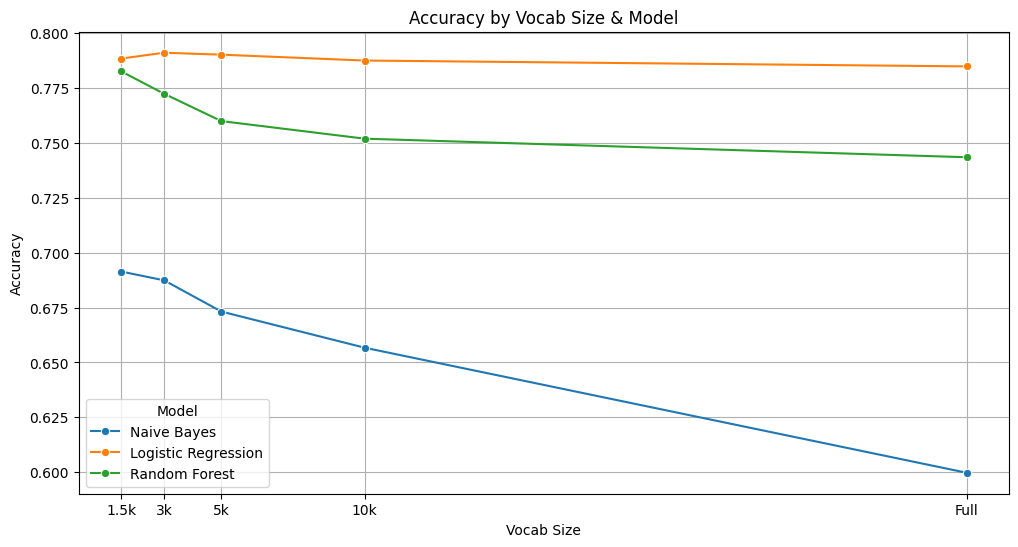

In [25]:
# 1. 에러 수정을 위해 데이터프레임 복사
df_plot = df_results.copy()

# 2. "Full" 문자열을 그래프에 표시될 적당한 숫자(예: 31000)로 변경
# Reuters 전체 단어 수가 대략 3만 개 정도 됩니다.
df_plot['Vocab Size'] = df_plot['Vocab Size'].replace("Full", 31000)

# 3. 데이터 타입을 숫자로 강제 변환 (안전장치)
df_plot['Vocab Size'] = pd.to_numeric(df_plot['Vocab Size'])

# 4. 시각화 다시 실행
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_plot, x="Vocab Size", y="Accuracy", hue="Model", marker='o')

# X축 눈금을 예쁘게 만들기 위해 "Full" 위치에 텍스트 표시 (선택 사항)
plt.xticks(ticks=[1500, 3000, 5000, 10000, 31000], labels=['1.5k', '3k', '5k', '10k', 'Full'])

plt.title("Accuracy by Vocab Size & Model")
plt.grid(True)
plt.show()

단어를 많이 사용할수록 정확도가 떨어진다.

In [17]:
from sklearn.ensemble import HistGradientBoostingClassifier

# 1. Reuters 데이터를 텍스트로 복원하는 함수 (CountVectorizer 사용을 위해)
def decode_reuters(x_data):
    word_index = reuters.get_word_index()
    index_to_word = {i+3: word for word, i in word_index.items()}
    for i, word in enumerate(('<pad>', '<sos>', '<unk>')):
        index_to_word[i] = word

    decoded_docs = []
    for sequence in x_data:
        decoded_docs.append(' '.join([index_to_word.get(i, '?') for i in sequence]))
    return decoded_docs

# 2. 실험 설정
vocab_sizes = [1500, 3000, 5000, None] # None은 모든 단어 사용
models = {
    "Logi Reg": LogisticRegression(penalty='l2', max_iter=500), # max_iter 조정
    "Random Forest": RandomForestClassifier(n_estimators=50, n_jobs=-1), # 나무 개수 조정
    "SVM (Fast)": LinearSVC(C=1.0, penalty='l2', max_iter=1000), # C값 현실화, l2 사용
    "XGBoost (Fast)": XGBClassifier(n_estimators=100, max_depth=5, use_label_encoder=False, missing=0), # 깊이와 개수 조절
    "LightGBM": HistGradientBoostingClassifier()
}

results = []

# 3. 실험 루프
for size in vocab_sizes:
    print(f"--- Experimenting with Vocab Size: {size if size else 'All'} ---")

    # 데이터 로드
    (x_train, y_train), (x_test, y_test) = reuters.load_data(num_words=size, test_split=0.2)

    # 텍스트 복원
    x_train_text = decode_reuters(x_train)
    x_test_text = decode_reuters(x_test)

    # TF-IDF 벡터화
    dtmvector = CountVectorizer()
    x_train_dtm = dtmvector.fit_transform(x_train_text)
    x_test_dtm = dtmvector.transform(x_test_text)

    tfidf_transformer = TfidfTransformer()
    x_train_tfidf = tfidf_transformer.fit_transform(x_train_dtm)
    x_test_tfidf = tfidf_transformer.transform(x_test_dtm)

    # 모델별 학습 및 평가
    for name, model in models.items():
        print(f"현재 학습 중: {name} (Vocab Size: {size if size else 'Full'})")

        # 1. Dense 데이터가 필요한 모델들 체크 (Boosting 계열 등)
        # 만약 메모리가 부족하면 이 모델들은 'Full' 사이즈에서 제외하는 게 좋습니다.
        if name in ["Gradient Boosting", "XGBoost", "LightGBM"]:
            x_train_input = x_train_tfidf.toarray()
            x_test_input = x_test_tfidf.toarray()
        else:
            # Naive Bayes, Logistic Regression, SVM 등은 Sparse 그대로 쓰는 게 훨씬 빠릅니다.
            x_train_input = x_train_tfidf
            x_test_input = x_test_tfidf

        # 2. 학습 및 예측
        model.fit(x_train_input, y_train)
        predicted = model.predict(x_test_input)

        # 3. 결과 기록
        acc = accuracy_score(y_test, predicted)
        f1 = f1_score(y_test, predicted, average='weighted')

        results.append({
            "Vocab Size": size if size else "Full",
            "Model": name,
            "Accuracy": acc,
            "F1 Score": f1
        })

# 4. 결과 정리
df_results = pd.DataFrame(results)
print("\n[실험 결과 요약]")
print(df_results)

--- Experimenting with Vocab Size: 1500 ---
현재 학습 중: Logi Reg (Vocab Size: 1500)
현재 학습 중: Random Forest (Vocab Size: 1500)
현재 학습 중: SVM (Fast) (Vocab Size: 1500)
현재 학습 중: XGBoost (Fast) (Vocab Size: 1500)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:21:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


현재 학습 중: LightGBM (Vocab Size: 1500)
--- Experimenting with Vocab Size: 3000 ---
현재 학습 중: Logi Reg (Vocab Size: 3000)
현재 학습 중: Random Forest (Vocab Size: 3000)
현재 학습 중: SVM (Fast) (Vocab Size: 3000)
현재 학습 중: XGBoost (Fast) (Vocab Size: 3000)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:23:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


현재 학습 중: LightGBM (Vocab Size: 3000)
--- Experimenting with Vocab Size: 5000 ---
현재 학습 중: Logi Reg (Vocab Size: 5000)
현재 학습 중: Random Forest (Vocab Size: 5000)
현재 학습 중: SVM (Fast) (Vocab Size: 5000)
현재 학습 중: XGBoost (Fast) (Vocab Size: 5000)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:27:15] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


현재 학습 중: LightGBM (Vocab Size: 5000)
--- Experimenting with Vocab Size: All ---
현재 학습 중: Logi Reg (Vocab Size: Full)
현재 학습 중: Random Forest (Vocab Size: Full)
현재 학습 중: SVM (Fast) (Vocab Size: Full)
현재 학습 중: XGBoost (Fast) (Vocab Size: Full)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:32:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


현재 학습 중: LightGBM (Vocab Size: Full)

[실험 결과 요약]
   Vocab Size           Model  Accuracy  F1 Score
0        1500        Logi Reg  0.794301  0.769610
1        1500   Random Forest  0.771594  0.751452
2        1500      SVM (Fast)  0.829475  0.822643
3        1500  XGBoost (Fast)  0.807658  0.799117
4        1500        LightGBM  0.217275  0.235660
5        3000        Logi Reg  0.798753  0.777560
6        3000   Random Forest  0.776492  0.757228
7        3000      SVM (Fast)  0.829029  0.822879
8        3000  XGBoost (Fast)  0.801425  0.793273
9        3000        LightGBM  0.321015  0.176163
10       5000        Logi Reg  0.797863  0.776227
11       5000   Random Forest  0.760908  0.738228
12       5000      SVM (Fast)  0.829029  0.822996
13       5000  XGBoost (Fast)  0.804096  0.797436
14       5000        LightGBM  0.211487  0.076271
15       Full        Logi Reg  0.791630  0.767021
16       Full   Random Forest  0.736866  0.710018
17       Full      SVM (Fast)  0.829475  0.823668
1

In [18]:
#  데이터를 표 형식으로 재구성
# 인덱스는 'Vocab Size', 열은 'Model', 값은 'Accuracy'와 'F1 Score'
pivot_df = df_results.pivot(index='Vocab Size', columns='Model', values=['Accuracy', 'F1 Score'])

# 현재: (지표, 모델) -> 변경: (모델, 지표)
pivot_df = pivot_df.swaplevel(0, 1, axis=1).sort_index(axis=1)

# 인덱스(Vocab Size) 순서 정렬 -> 오름차순
pivot_df.index = pivot_df.index.astype(str)
pivot_df = pivot_df.reindex(["1500", "3000", "5000", "10000", "Full"])

print("\n[최종 실험 결과 표]")
display(pivot_df)


[최종 실험 결과 표]


Model       LightGBM            Logi Reg           Random Forest            \
            Accuracy  F1 Score  Accuracy  F1 Score      Accuracy  F1 Score   
Vocab Size                                                                   
1500        0.217275  0.235660  0.794301  0.769610      0.771594  0.751452   
3000        0.321015  0.176163  0.798753  0.777560      0.776492  0.757228   
5000        0.211487  0.076271  0.797863  0.776227      0.760908  0.738228   
10000            NaN       NaN       NaN       NaN           NaN       NaN   
Full        0.205699  0.219160  0.791630  0.767021      0.736866  0.710018   

Model      SVM (Fast)           XGBoost (Fast)            
             Accuracy  F1 Score       Accuracy  F1 Score  
Vocab Size                                                
1500         0.829475  0.822643       0.807658  0.799117  
3000         0.829029  0.822879       0.801425  0.793273  
5000         0.829029  0.822996       0.804096  0.797436  
10000             NaN       NaN            NaN       NaN  
Full         0.829475  0.823668       0.800534  0.793342

In [31]:
# 1. Reuters 데이터를 텍스트로 복원하는 함수 (CountVectorizer 사용을 위해)
def decode_reuters(x_data):
    word_index = reuters.get_word_index()
    index_to_word = {i+3: word for word, i in word_index.items()}
    for i, word in enumerate(('<pad>', '<sos>', '<unk>')):
        index_to_word[i] = word

    decoded_docs = []
    for sequence in x_data:
        decoded_docs.append(' '.join([index_to_word.get(i, '?') for i in sequence]))
    return decoded_docs

# 2. 실험 설정
vocab_sizes = [10000]
models = {
    "Logi Reg": LogisticRegression(penalty='l2', max_iter=500),
    "Random Forest": RandomForestClassifier(n_estimators=50, n_jobs=-1),
    "SVM (Fast)": LinearSVC(C=1.0, penalty='l2', max_iter=1000, dual=True),
    "XGBoost (Fast)": XGBClassifier(n_estimators=100, max_depth=5, eval_metric='mlogloss'),
    "LightGBM": HistGradientBoostingClassifier()
}

results = []

# 3. 실험 루프
for size in vocab_sizes:
    print(f"--- Experimenting with Vocab Size: {size if size else 'All'} ---")

    # 데이터 로드
    (x_train, y_train), (x_test, y_test) = reuters.load_data(num_words=size, test_split=0.2)

    # 텍스트 복원
    x_train_text = decode_reuters(x_train)
    x_test_text = decode_reuters(x_test)

    # TF-IDF 벡터화
    dtmvector = CountVectorizer()
    x_train_dtm = dtmvector.fit_transform(x_train_text)
    x_test_dtm = dtmvector.transform(x_test_text)

    tfidf_transformer = TfidfTransformer()
    x_train_tfidf = tfidf_transformer.fit_transform(x_train_dtm)
    x_test_tfidf = tfidf_transformer.transform(x_test_dtm)

    # 모델별 학습 및 평가
for name, model in models.items():
        print(f"학습 중: {name}...")

        if name in ["XGBoost (Fast)", "LightGBM"]:
            x_train_input = x_train_tfidf.toarray()
            x_test_input = x_test_tfidf.toarray()
        else:
            x_train_input = x_train_tfidf
            x_test_input = x_test_tfidf
        # ---------------------------------------------------------

        model.fit(x_train_input, y_train)
        predicted = model.predict(x_test_input)

        acc = accuracy_score(y_test, predicted)
        f1 = f1_score(y_test, predicted, average='weighted')

        results.append({
            "Vocab Size": str(size),
            "Model": name,
            "Accuracy": acc,
            "F1 Score": f1
        })

# 4. 결과 정리
df_results = pd.DataFrame(results)
print("\n[10000개 실험 결과 요약]")
display(df_results)

--- Experimenting with Vocab Size: 10000 ---
학습 중: Logi Reg...
학습 중: Random Forest...
학습 중: SVM (Fast)...
학습 중: XGBoost (Fast)...
학습 중: LightGBM...

[10000개 실험 결과 요약]


,Vocab Size,Model,Accuracy,F1 Score
0,10000,Logi Reg,0.795637,0.773208
1,10000,Random Forest,0.748887,0.725384
2,10000,SVM (Fast),0.829920,0.823688
3,10000,XGBoost (Fast),0.802315,0.795520
4,10000,LightGBM,0.075690,0.059475


In [45]:
def decode_reuters(x_data):
    word_index = reuters.get_word_index()
    index_to_word = {i+3: word for word, i in word_index.items()}
    for i, word in enumerate(('<pad>', '<sos>', '<unk>')):
        index_to_word[i] = word

    decoded_docs = []
    for sequence in x_data:
        decoded_docs.append(' '.join([index_to_word.get(i, '?') for i in sequence]))
    return decoded_docs

# 2. 실험 설정
vocab_sizes = [5000, 10000]
models = {
    "SVM (Default)": LinearSVC(C=1.0, dual='auto'),
    "SVM (Harder)": LinearSVC(C=10.0, dual='auto'), # 조금 더 깐깐하게
    "SVM (Balanced)": LinearSVC(C=1.0, class_weight='balanced', dual='auto'), # 불균형 해결
}

results = []

# 3. 실험 루프
for size in vocab_sizes:
    print(f"--- Experimenting with Vocab Size: {size if size else 'All'} ---")

    # 데이터 로드
    (x_train, y_train), (x_test, y_test) = reuters.load_data(num_words=size, test_split=0.2)

    # 텍스트 복원
    x_train_text = decode_reuters(x_train)
    x_test_text = decode_reuters(x_test)

    # TF-IDF 벡터화
    dtmvector = CountVectorizer()
    x_train_dtm = dtmvector.fit_transform(x_train_text)
    x_test_dtm = dtmvector.transform(x_test_text)

    tfidf_transformer = TfidfTransformer()
    x_train_tfidf = tfidf_transformer.fit_transform(x_train_dtm)
    x_test_tfidf = tfidf_transformer.transform(x_test_dtm)

    # 모델별 학습 및 평가
    for name, model in models.items():
        model.fit(x_train_tfidf, y_train)
        predicted = model.predict(x_test_tfidf)

        acc = accuracy_score(y_test, predicted)
        f1 = f1_score(y_test, predicted, average='weighted')

        results.append({
            "Vocab Size": size if size else "Full",
            "Model": name,
            "Accuracy": acc,
            "F1 Score": f1
        })

# 4. 결과 정리
df_results = pd.DataFrame(results)
print("\n[실험 결과 요약]")
display(df_results)

--- Experimenting with Vocab Size: 5000 ---
--- Experimenting with Vocab Size: 10000 ---

[실험 결과 요약]


,Vocab Size,Model,Accuracy,F1 Score
0,5000,SVM (Default),0.829029,0.822996
1,5000,SVM (Harder),0.806322,0.801771
2,5000,SVM (Balanced),0.834372,0.836098
3,10000,SVM (Default),0.829920,0.823688
4,10000,SVM (Harder),0.813001,0.809061
5,10000,SVM (Balanced),0.831701,0.832263


## Dense NN 딥러닝 모델

In [35]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout, LSTM, Dense, Dropout


# 아래 Dense의 레이어를 바꿔가며 성능을 확인해봅시다

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout

input_dim = x_train_tfidf.shape[1]

inputs = Input(shape=(input_dim,))

x = Dense(512, activation='relu')(inputs)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(46, activation='softmax')(x)  # 클래스 46개

dense_model = Model(inputs=inputs, outputs=outputs)

dense_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
dense_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 9670)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │     4,951,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 46)             │         5,934 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,023,150 (19.16 MB)

 Trainable params: 5,023,150 (19.16 MB)

 Non-trainable params: 0 (0.00 B)

In [36]:
dense_model.fit(x_train_tfidf, y_train, epochs=10, batch_size=32, validation_split=0.2)

Epoch 1/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 287s 1s/step - accuracy: 0.5052 - loss: 2.2709 - val_accuracy: 0.7551 - val_loss: 1.0878
Epoch 2/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 214s 949ms/step - accuracy: 0.8034 - loss: 0.8594 - val_accuracy: 0.8041 - val_loss: 0.8698
Epoch 3/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 191s 846ms/step - accuracy: 0.8924 - loss: 0.4682 - val_accuracy: 0.8063 - val_loss: 0.8578
Epoch 4/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 165s 732ms/step - accuracy: 0.9290 - loss: 0.2879 - val_accuracy: 0.8086 - val_loss: 0.8854
Epoch 5/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 151s 673ms/step - accuracy: 0.9561 - loss: 0.1866 - val_accuracy: 0.8186 - val_loss: 0.8871
Epoch 6/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 116s 518ms/step - accuracy: 0.9596 - loss: 0.1484 - val_accuracy: 0.8136 - val_loss: 0.9011
Epoch 7/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 107s 476ms/step - accuracy: 0.9598 - loss: 0.1325 - val_accuracy: 0.8208 - val_loss: 0.9380
Epoch 8/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 86s 383ms/step - accuracy: 0.9680 - los

In [37]:
y_pred_proba = dense_model.predict(x_test_tfidf)
y_pred = np.argmax(y_pred_proba, axis=1)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"✅ Accuracy: {acc:.4f}")
print(f"✅ F1-score: {f1:.4f}")

71/71 ━━━━━━━━━━━━━━━━━━━━ 14s 193ms/step
✅ Accuracy: 0.8014
✅ F1-score: 0.7938


In [46]:
input_dim = x_train_tfidf.shape[1] # 현재 데이터의 크기(예: 4867)를 자동으로 읽음

inputs = Input(shape=(input_dim,))
x = Dense(512, activation='relu')(inputs)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(46, activation='softmax')(x)

dense_model = Model(inputs=inputs, outputs=outputs)
dense_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = dense_model.fit(
    x_train_tfidf.toarray(), y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# 2. 테스트 데이터로 예측 및 평가
# 확률값으로 나오기 때문에 argmax로 가장 높은 확률의 인덱스를 뽑습니다.
y_prob = dense_model.predict(x_test_tfidf.toarray())
y_pred = y_prob.argmax(axis=-1)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

# 3. 기존 results 리스트에 결과 추가
results.append({
    "Vocab Size": "10000", # 현재 실험 중인 보카 사이즈
    "Model": "Deep Learning",
    "Accuracy": acc,
    "F1 Score": f1
})

# 4. 최종 결과 표 업데이트
df_results = pd.DataFrame(results)
df_results['Vocab Size'] = df_results['Vocab Size'].astype(str) # 타입 통일

# 피벗 테이블 생성
pivot_df = df_results.pivot_table(index='Vocab Size', columns='Model', values=['Accuracy', 'F1 Score'], aggfunc='last')
pivot_df = pivot_df.swaplevel(0, 1, axis=1).sort_index(axis=1)

display(pivot_df)

Epoch 1/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.4806 - loss: 2.3238 - val_accuracy: 0.7307 - val_loss: 1.1411
Epoch 2/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7828 - loss: 0.9331 - val_accuracy: 0.7980 - val_loss: 0.9024
Epoch 3/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8573 - loss: 0.5953 - val_accuracy: 0.8180 - val_loss: 0.8265
Epoch 4/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9046 - loss: 0.3857 - val_accuracy: 0.8230 - val_loss: 0.8194
Epoch 5/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9320 - loss: 0.2665 - val_accuracy: 0.8230 - val_loss: 0.8381
Epoch 6/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9478 - loss: 0.2059 - val_accuracy: 0.8186 - val_loss: 0.8813
Epoch 7/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9557 - loss: 0.1585 - val_accuracy: 0.8147 - val_loss: 0.9150
Epoch 8/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9643 - loss: 0.1306 - val_accuracy: 0

Model      Deep Learning           SVM (Balanced)           SVM (Default)  \
                Accuracy  F1 Score       Accuracy  F1 Score      Accuracy   
Vocab Size                                                                  
10000           0.806768  0.800169       0.831701  0.832263      0.829920   
5000                 NaN       NaN       0.834372  0.836098      0.829029   

Model                SVM (Harder)            
            F1 Score     Accuracy  F1 Score  
Vocab Size                                   
10000       0.823688     0.813001  0.809061  
5000        0.822996     0.806322  0.801771